# HP Search Analysis

Loads runs saved by `scripts/python/download_wandb_runs.py`, aggregates over seeds,
visualises loss curves and training stats, and recommends the best HP combination.

**Workflow**
1. Run `python scripts/python/download_wandb_runs.py --group <stage>` first.
2. Set `GROUP` in Cell 1 to the downloaded group name.
3. Run all cells. The recommendation prints at the bottom.

Selection rule (from `docs/gnn_only_hp_search_plan.md`):
rank by **min val/loss_total over the last 10 epochs, mean over seeds**.
Test MSE is shown as an overfit guard only — not the selection signal.

In [1]:
# ── Cell 1: Imports and configuration ─────────────────────────────────────────
from __future__ import annotations
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

try:
    import seaborn as sns
    _HAS_SEABORN = True
except ImportError:
    _HAS_SEABORN = False
    warnings.warn('seaborn not installed; heatmap will use matplotlib')

# ── USER CONFIG ────────────────────────────────────────────────────────────────
GROUP  = 'stage_5c_tier_b_confirm'   # <- edit to switch stages
GROUPS = ["stage_0c_tier_b", "stage_1e_tier_b_lr", "stage_1e_refine_tier_b_lr", "stage_5c_tier_b_confirm"]          # <- set to list for multi-group comparison (Cell 14)

# Per-property val-MSE gates: Stage 0c 6-prop floor (5-seed val_min_last10 mean,
# 2026-04-28). Tier B Stage 5c must beat these. Earlier Tier A gates (Stage 0b
# 4-prop floor) preserved in commented block below for reference.
GATES = {
    'lipid_packing': 0.019,
    'thickness':     0.067,
    'thickness_std': 0.302,
    'variation':     0.151,
    'persistence':   0.362,
    'diffusivity':   0.059,
}
# Tier A (Stage 0b 4-prop) historic gates:
# {'lipid_packing': 0.022, 'thickness': 0.074, 'thickness_std': 0.359, 'variation': 0.462}
OCCAM_TOL = 0.01          # prefer smaller arch when score within this fraction

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})


def _find_repo_root() -> Path:
    p = Path('.').resolve()
    for _ in range(6):
        if (p / 'config.yaml').exists():
            return p
        p = p.parent
    raise FileNotFoundError('Cannot find repo root (config.yaml not found in parents)')


REPO_ROOT = _find_repo_root()
LOGS_DIR  = REPO_ROOT / 'logs' / 'training'
print(f'REPO_ROOT : {REPO_ROOT}')
print(f'LOGS_DIR  : {LOGS_DIR}')
print(f'GROUP     : {GROUP}')

REPO_ROOT : /home/phillip/Goethe/Thesis/lipid-graph-nn
LOGS_DIR  : /home/phillip/Goethe/Thesis/lipid-graph-nn/logs/training
GROUP     : stage_5c_tier_b_confirm


In [2]:
# ── Cell 2: Load helper ────────────────────────────────────────────────────────
def _parse_gpu_memory(sys_df: pd.DataFrame) -> float:
    """Peak GPU memory in MB; picks the active GPU (max across all gpu.N.memoryAllocated columns).

    W&B reports all visible GPUs but only the SLURM-allocated one has non-zero values.
    The allocated index varies per job, so we scan all columns and take the maximum.
    """
    if sys_df.empty:
        return float('nan')
    best = float('nan')
    for col in sys_df.columns:
        low = col.lower()
        if 'memoryallocated' in low and 'gpu' in low:
            vals = sys_df[col].dropna()
            if vals.empty or vals.max() == 0:
                continue
            # Values are percentage (0-100) of total GPU memory
            val = float(vals.max() / 100 * 64 * 1024)  # % of MI210 64 GB -> MB
            if np.isnan(best) or val > best:
                best = val
    return best


def _parse_gpu_util(sys_df: pd.DataFrame) -> float:
    """Mean GPU utilisation %; picks the active GPU (highest mean across all gpu.N.gpu columns).

    W&B reports all visible GPUs but only the SLURM-allocated one has non-zero values.
    """
    if sys_df.empty:
        return float('nan')
    best_mean = float('nan')
    for col in sys_df.columns:
        if col.lower().endswith('.gpu') and 'gpu' in col.lower():
            vals = sys_df[col].dropna()
            if vals.empty:
                continue
            m = float(vals.mean())
            if np.isnan(best_mean) or m > best_mean:
                best_mean = m
    return best_mean


def _tail_min(hist: pd.DataFrame, col: str) -> float:
    if hist.empty or col not in hist.columns:
        return float('nan')
    s = hist[col].dropna()
    return float(s.tail(10).min()) if len(s) else float('nan')


def _tail_mean(hist: pd.DataFrame, col: str) -> float:
    """Mean over last 10 epochs. Used for noisy per-epoch metrics like R²,
    where val_min_last10 (used for MSE) would amplify favourable noise spikes.
    """
    if hist.empty or col not in hist.columns:
        return float('nan')
    s = hist[col].dropna()
    return float(s.tail(10).mean()) if len(s) else float('nan')


def load_group(group: str) -> tuple[pd.DataFrame, dict, dict]:
    """Load all downloaded runs for *group*.

    Returns
    -------
    runs_df        one row per run with config + derived stats
    histories      {run_id: history_df} for loss plotting
    sys_histories  {run_id: system_df}  for utilisation plotting
    """
    group_dir  = LOGS_DIR / group
    index_path = group_dir / 'runs_index.json'
    if not index_path.exists():
        raise FileNotFoundError(
            f'No index at {index_path}.\n'
            f'Run: python scripts/python/download_wandb_runs.py --group {group}'
        )
    with open(index_path) as f:
        index = json.load(f)

    rows, histories, sys_histories = [], {}, {}

    for entry in index:
        name    = entry['name']
        run_dir = group_dir / name
        cfg     = entry['config']
        props   = cfg.get('properties', [])

        hp      = run_dir / 'history.parquet'
        hist    = pd.read_parquet(hp) if hp.exists() else pd.DataFrame()
        sp      = run_dir / 'system.parquet'
        sys_df  = pd.read_parquet(sp) if sp.exists() else pd.DataFrame()
        sump    = run_dir / 'summary.json'
        summary = json.loads(sump.read_text()) if sump.exists() else {}

        runtime = entry.get('runtime_seconds') or summary.get('_runtime')
        epochs  = cfg.get('epochs', 100)
        vml10   = _tail_min(hist, 'val/loss_total')
        test_mse = summary.get('test/mse_total', float('nan'))

        row = {
            'run_id': entry['id'],
            'run_name': name,
            'group': group,
            'state': entry['state'],
            # scalar config keys flattened
            **{k: v for k, v in cfg.items()
               if isinstance(v, (int, float, str, bool)) and k != 'properties'},
            'properties_str':   ','.join(props),
            'val_min_last10':   vml10,
            'test_mse_total':   float(test_mse) if test_mse is not None else float('nan'),
            'runtime_seconds':  runtime,
            'sec_per_epoch':    (runtime / epochs) if runtime else float('nan'),
            'peak_gpu_mem_mb':  _parse_gpu_memory(sys_df),
            'mean_gpu_util_pct': _parse_gpu_util(sys_df),
        }
        for prop in props:
            row[f'val_min_{prop}'] = _tail_min(hist, f'val/loss_{prop}')
            row[f'val_r2_{prop}']  = _tail_mean(hist, f'val/r2_{prop}')

        tm, vm = row['test_mse_total'], row['val_min_last10']
        row['gap'] = abs(tm - vm) if not (np.isnan(tm) or np.isnan(vm)) else float('nan')

        rows.append(row)
        histories[entry['id']]     = hist
        sys_histories[entry['id']] = sys_df

    df = pd.DataFrame(rows)
    print(f"Loaded {len(df)} runs from '{group}'")
    return df, histories, sys_histories

In [3]:
# ── Cell 3: Load data ──────────────────────────────────────────────────────────
runs_df, histories, sys_histories = load_group(GROUP)

PROPS = [
    c.replace('val_min_', '')
    for c in runs_df.columns
    if c.startswith('val_min_') and c != 'val_min_last10'
]
print(f'Properties : {PROPS}')
runs_df.head()

Loaded 5 runs from 'stage_5c_tier_b_confirm'
Properties : ['lipid_packing', 'thickness', 'thickness_std', 'variation', 'persistence', 'diffusivity']


,run_id,run_name,group,state,seed,epochs,comp_mode,batch_size,hidden_dim,num_layers,...,val_r2_thickness,val_min_thickness_std,val_r2_thickness_std,val_min_variation,val_r2_variation,val_min_persistence,val_r2_persistence,val_min_diffusivity,val_r2_diffusivity,gap
0,1g1fqcf3,gnn_only_h128_l2_lr3e-05_wd1e-03_e200_s1_1g1fqcf3,stage_5c_tier_b_confirm,finished,1,200,gnn_only,2,128,2,...,0.943502,0.295388,0.642905,0.075927,0.949085,0.329411,0.691966,0.065899,0.951150,0.024289
1,ilmfli0c,gnn_only_h128_l2_lr3e-05_wd1e-03_e200_s0_ilmfli0c,stage_5c_tier_b_confirm,finished,0,200,gnn_only,2,128,2,...,0.938110,0.305586,0.628994,0.151616,0.897260,0.366194,0.655849,0.065965,0.950788,0.024118
2,vziwn62y,gnn_only_h128_l2_lr3e-05_wd1e-03_e200_s5_vziwn62y,stage_5c_tier_b_confirm,finished,5,200,gnn_only,2,128,2,...,0.944183,0.289637,0.650133,0.063267,0.957637,0.320641,0.700319,0.055736,0.958774,0.017968
3,7bb7c4lk,gnn_only_h128_l2_lr3e-05_wd1e-03_e200_s3_7bb7c4lk,stage_5c_tier_b_confirm,finished,3,200,gnn_only,2,128,2,...,0.948769,0.285879,0.653578,0.069246,0.953510,0.329194,0.692265,0.062139,0.953903,0.020038
4,cyzic1qk,gnn_only_h128_l2_lr3e-05_wd1e-03_e200_s4_cyzic1qk,stage_5c_tier_b_confirm,finished,4,200,gnn_only,2,128,2,...,0.942989,0.292612,0.645150,0.078775,0.946804,0.366858,0.655623,0.064541,0.952045,0.027820


In [4]:
# ── Cell 4: Auto-detect varying hyperparameters ────────────────────────────────
_META = {
    'run_id', 'run_name', 'group', 'state', 'properties_str',
    'val_min_last10', 'test_mse_total', 'gap',
    'runtime_seconds', 'sec_per_epoch', 'peak_gpu_mem_mb', 'mean_gpu_util_pct',
    'properties',
}
# Exclude both per-property MSE (val_min_*) and R² (val_r2_*) from HP detection.
_PROP_VALS = {
    c for c in runs_df.columns
    if (c.startswith('val_min_') and c != 'val_min_last10') or c.startswith('val_r2_')
}
_INFRA     = {'epochs', 'batch_size', 'num_workers', 'seed'}

HP_COLS = [
    c for c in runs_df.columns
    if c not in _META and c not in _PROP_VALS and c not in _INFRA
]

VARYING_HPS = [c for c in HP_COLS if runs_df[c].nunique() > 1]
FIXED_HPS   = [c for c in HP_COLS if runs_df[c].nunique() <= 1]

print(f'Varying HPs : {VARYING_HPS}')
print(f'Fixed HPs   : {[(c, runs_df[c].iloc[0]) for c in FIXED_HPS]}')
print(f'Seeds       : {sorted(runs_df["seed"].unique())}')

Varying HPs : []
Fixed HPs   : [('comp_mode', 'gnn_only'), ('hidden_dim', np.int64(128)), ('num_layers', np.int64(2)), ('weight_decay', np.float64(0.001)), ('learning_rate', np.float64(3e-05))]
Seeds       : [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)]


In [5]:
# ── Cell 5: Aggregate over seeds ───────────────────────────────────────────────
GROUP_BY = VARYING_HPS if VARYING_HPS else (['comp_mode'] if 'comp_mode' in runs_df.columns else ['run_name'])


def _agg_cells(df: pd.DataFrame, group_by: list[str]) -> pd.DataFrame:
    """Collapse seed dimension; compute mean/std for each HP cell.

    Per-property metrics:
      val_{prop}  — seed-mean of val_min_last10 of val/loss_{prop}  (selection metric)
      r2_{prop}   — seed-mean of last-10-epoch mean of val/r2_{prop} (reporting metric)
    """
    rows = []
    for keys, grp in df.groupby(group_by, sort=True):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row: dict = dict(zip(group_by, keys))
        row['n_seeds']      = len(grp)
        row['val_mean']     = grp['val_min_last10'].mean()
        row['val_std']      = grp['val_min_last10'].std()
        row['test_mean']    = grp['test_mse_total'].mean()
        row['test_std']     = grp['test_mse_total'].std()
        row['runtime_mean'] = grp['runtime_seconds'].mean()
        row['runtime_std']  = grp['runtime_seconds'].std()
        row['sec_per_epoch'] = grp['sec_per_epoch'].mean()
        row['gpu_mem_mb']   = grp['peak_gpu_mem_mb'].max()     # max across seeds
        row['gpu_util_pct'] = grp['mean_gpu_util_pct'].mean()
        for prop in PROPS:
            mse_col = f'val_min_{prop}'
            r2_col  = f'val_r2_{prop}'
            row[f'val_{prop}'] = grp[mse_col].mean() if mse_col in grp.columns else float('nan')
            row[f'r2_{prop}']  = grp[r2_col].mean()  if r2_col  in grp.columns else float('nan')
        tm, vm = row['test_mean'], row['val_mean']
        row['gap'] = abs(tm - vm) if not (np.isnan(tm) or np.isnan(vm)) else float('nan')
        rows.append(row)
    return pd.DataFrame(rows).sort_values('val_mean').reset_index(drop=True)


cells_df = _agg_cells(runs_df, GROUP_BY)
print(f'HP cells: {len(cells_df)}, grouped by {GROUP_BY}')
cells_df

HP cells: 1, grouped by ['comp_mode']


,comp_mode,n_seeds,val_mean,val_std,test_mean,test_std,runtime_mean,runtime_std,sec_per_epoch,gpu_mem_mb,...,r2_thickness,val_thickness_std,r2_thickness_std,val_variation,r2_variation,val_persistence,r2_persistence,val_diffusivity,r2_diffusivity,gap
0,gnn_only,5,0.147133,0.011444,0.124287,0.009804,10366.8,113.838482,51.834,64880.64,...,0.943511,0.293821,0.644152,0.087766,0.940859,0.34246,0.679205,0.062856,0.953332,0.022847


## Visualisations

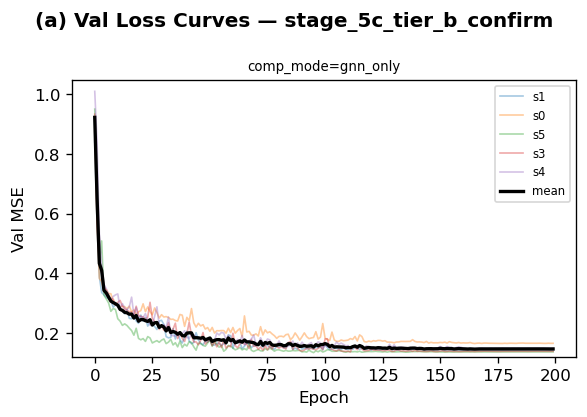

In [6]:
# ── (a) Val-loss curves per HP cell ────────────────────────────────────────────
n_cells = len(cells_df)
ncols   = min(3, n_cells)
nrows   = max(1, int(np.ceil(n_cells / ncols)))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows), squeeze=False)

all_val = [h['val/loss_total'].dropna() for h in histories.values() if 'val/loss_total' in h]
y_max = float(np.nanpercentile([v.max() for v in all_val], 95)) if all_val else 1.0
y_min = float(np.nanmin([v.min() for v in all_val])) if all_val else 0.0

for idx, (_, cell_row) in enumerate(cells_df.iterrows()):
    ax = axes[idx // ncols][idx % ncols]
    title = ' | '.join(f'{k}={cell_row[k]}' for k in GROUP_BY)

    cell_runs = runs_df.copy()
    for k in GROUP_BY:
        cell_runs = cell_runs[cell_runs[k] == cell_row[k]]

    traces = []
    for _, r in cell_runs.iterrows():
        h = histories.get(r['run_id'], pd.DataFrame())
        if h.empty or 'val/loss_total' not in h.columns:
            continue
        v = h['val/loss_total'].dropna().values
        ax.plot(v, alpha=0.4, linewidth=1, label=f's{r["seed"]}')
        traces.append(v)

    if traces:
        ml = min(len(t) for t in traces)
        ax.plot(np.mean([t[:ml] for t in traces], axis=0),
                color='black', linewidth=2, label='mean')

    ax.set_title(title, fontsize=8)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Val MSE')
    ax.set_ylim(max(0.0, y_min * 0.9), y_max * 1.05)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.legend(fontsize=7)

for idx in range(n_cells, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(f'(a) Val Loss Curves — {GROUP}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

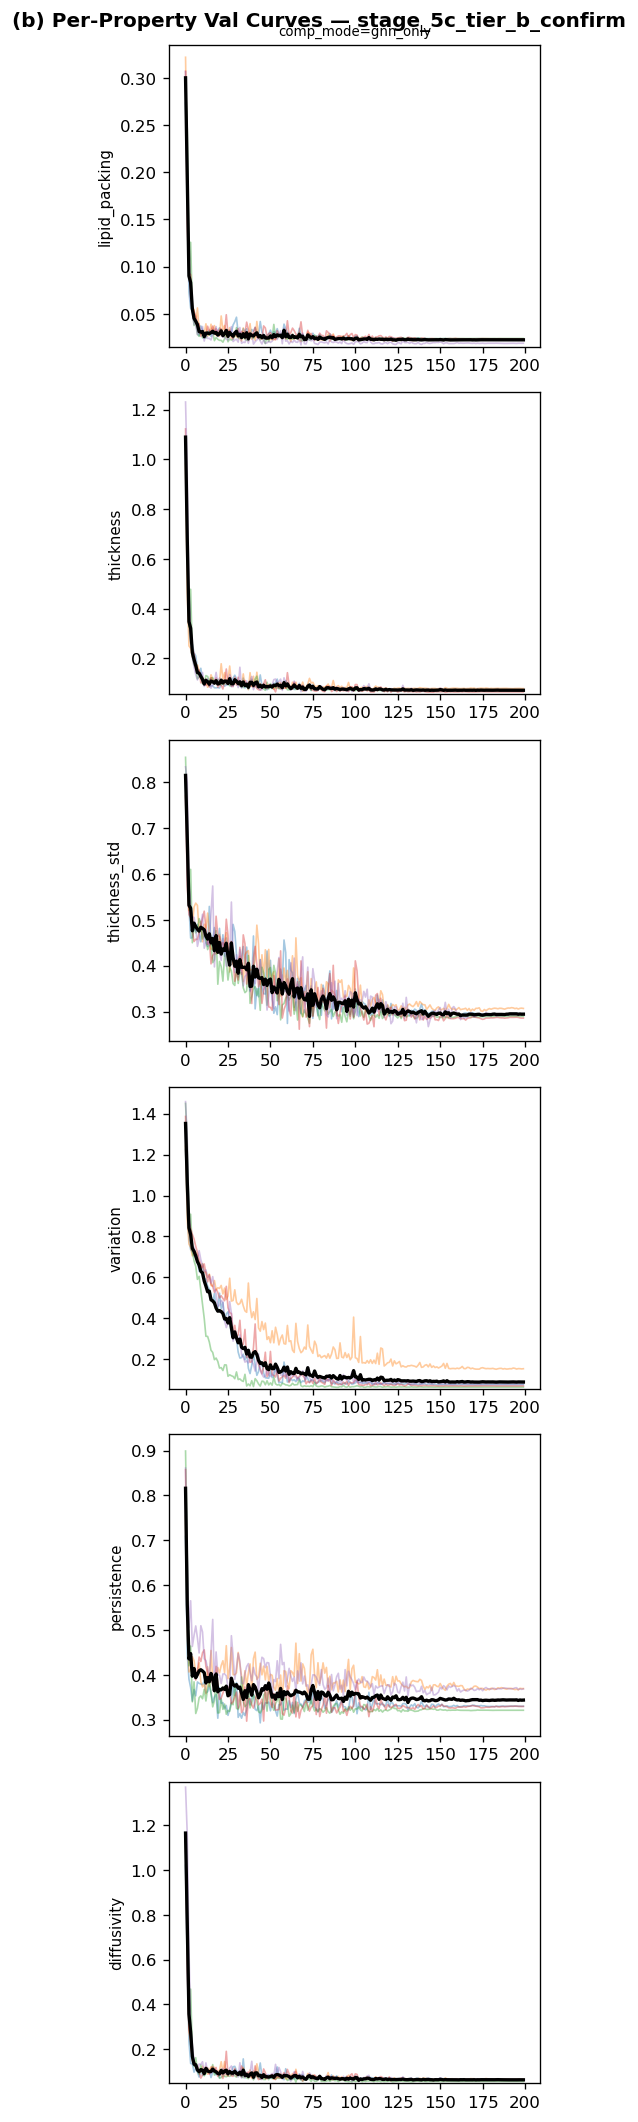

In [7]:
# ── (b) Per-property val curves ────────────────────────────────────────────────
if not PROPS:
    print('(b) No per-property columns found — skipping.')
else:
    n_p   = len(PROPS)
    fig, axes = plt.subplots(n_p, n_cells,
                              figsize=(4 * n_cells, 3 * n_p), squeeze=False)

    for pi, prop in enumerate(PROPS):
        col = f'val/loss_{prop}'
        prop_vals = [h[col].dropna() for h in histories.values() if col in h]
        pmax = float(np.nanpercentile([v.max() for v in prop_vals], 95)) if prop_vals else 1.0
        pmin = float(np.nanmin([v.min() for v in prop_vals])) if prop_vals else 0.0

        for ci, (_, cell_row) in enumerate(cells_df.iterrows()):
            ax = axes[pi][ci]
            cell_runs = runs_df.copy()
            for k in GROUP_BY:
                cell_runs = cell_runs[cell_runs[k] == cell_row[k]]

            traces = []
            for _, r in cell_runs.iterrows():
                h = histories.get(r['run_id'], pd.DataFrame())
                if h.empty or col not in h.columns:
                    continue
                v = h[col].dropna().values
                ax.plot(v, alpha=0.4, linewidth=1)
                traces.append(v)

            if traces:
                ml = min(len(t) for t in traces)
                ax.plot(np.mean([t[:ml] for t in traces], axis=0),
                        color='black', linewidth=2)

            if pi == 0:
                ax.set_title(' | '.join(f'{k}={cell_row[k]}' for k in GROUP_BY), fontsize=8)
            if ci == 0:
                ax.set_ylabel(prop, fontsize=9)
            ax.set_ylim(max(0.0, pmin * 0.9), pmax * 1.05)
            ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    fig.suptitle(f'(b) Per-Property Val Curves — {GROUP}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [8]:
# ── (c) Ranking table ──────────────────────────────────────────────────────────
# Show MSE and R² for each property side-by-side. MSE drives selection;
# R² is the more interpretable reporting metric (1 = perfect, 0 = chance).
disp_cols = GROUP_BY + ['n_seeds', 'val_mean', 'val_std', 'test_mean', 'gap']
for p in PROPS:
    disp_cols.append(f'val_{p}')
    disp_cols.append(f'r2_{p}')
disp_cols  = [c for c in disp_cols if c in cells_df.columns]

fmt = {'val_mean': '{:.4f}', 'val_std': '{:.4f}',
       'test_mean': '{:.4f}', 'gap': '{:.4f}'}
for p in PROPS:
    fmt[f'val_{p}'] = '{:.4f}'
    fmt[f'r2_{p}']  = '{:.3f}'

styled = (
    cells_df[disp_cols]
    .style
    .background_gradient(subset=['val_mean'], cmap='RdYlGn_r', axis=0)
    .format(fmt)
    .set_caption(f'(c) HP Ranking — {GROUP}   (sorted by val_mean, lower = better; R² higher = better)')
)
display(styled)

,comp_mode,n_seeds,val_mean,val_std,test_mean,gap,val_lipid_packing,r2_lipid_packing,val_thickness,r2_thickness,val_thickness_std,r2_thickness_std,val_variation,r2_variation,val_persistence,r2_persistence,val_diffusivity,r2_diffusivity
0,gnn_only,5,0.1471,0.0114,0.1243,0.0228,0.0223,0.935,0.0717,0.944,0.2938,0.644,0.0878,0.941,0.3425,0.679,0.0629,0.953


In [9]:
# ── (d) HP heatmap (only when exactly 2 HPs vary) ─────────────────────────────
if len(VARYING_HPS) != 2:
    print(f'(d) Heatmap skipped — need exactly 2 varying HPs, found {len(VARYING_HPS)}: {VARYING_HPS}')
else:
    dim_x, dim_y = VARYING_HPS[0], VARYING_HPS[1]
    pivot = cells_df.pivot(index=dim_y, columns=dim_x, values='val_mean')

    fig_w = max(5, len(pivot.columns) * 1.6)
    fig_h = max(4, len(pivot) * 1.3)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))

    if _HAS_SEABORN:
        sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn_r',
                    ax=ax, linewidths=0.5, cbar_kws={'label': 'val MSE'})
    else:
        im = ax.imshow(pivot.values, cmap='RdYlGn_r', aspect='auto')
        plt.colorbar(im, ax=ax, label='val MSE')
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_yticks(range(len(pivot.index)))
        ax.set_xticklabels(pivot.columns)
        ax.set_yticklabels(pivot.index)
        for i in range(len(pivot.index)):
            for j in range(len(pivot.columns)):
                ax.text(j, i, f"{pivot.values[i, j]:.4f}",
                        ha='center', va='center', fontsize=9)

    ax.set_title(f'(d) Val MSE Heatmap ({dim_y} x {dim_x}) — {GROUP}')
    ax.set_xlabel(dim_x)
    ax.set_ylabel(dim_y)
    plt.tight_layout()
    plt.show()

(d) Heatmap skipped — need exactly 2 varying HPs, found 0: []


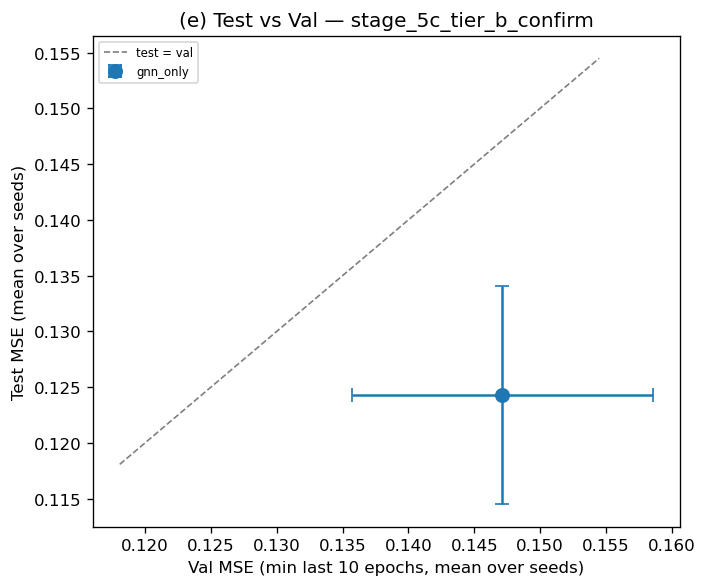

In [10]:
# ── (e) Test vs val scatter ────────────────────────────────────────────────────
valid = cells_df.dropna(subset=['val_mean', 'test_mean'])
if valid.empty:
    print('(e) Skipped — no runs with both val and test MSE.')
else:
    fig, ax = plt.subplots(figsize=(6, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, len(valid)))

    for i, (_, r) in enumerate(valid.iterrows()):
        label = ' | '.join(str(r[k]) for k in GROUP_BY)
        ax.errorbar(
            r['val_mean'], r['test_mean'],
            xerr=r.get('val_std', 0) or 0,
            yerr=r.get('test_std', 0) or 0,
            fmt='o', color=colors[i], markersize=8, capsize=4,
            label=label,
        )

    lo = min(valid['val_mean'].min(), valid['test_mean'].min()) * 0.95
    hi = max(valid['val_mean'].max(), valid['test_mean'].max()) * 1.05
    ax.plot([lo, hi], [lo, hi], 'k--', linewidth=1, alpha=0.5, label='test = val')

    ax.set_xlabel('Val MSE (min last 10 epochs, mean over seeds)')
    ax.set_ylabel('Test MSE (mean over seeds)')
    ax.set_title(f'(e) Test vs Val — {GROUP}')
    ax.legend(fontsize=7, loc='upper left')
    plt.tight_layout()
    plt.show()

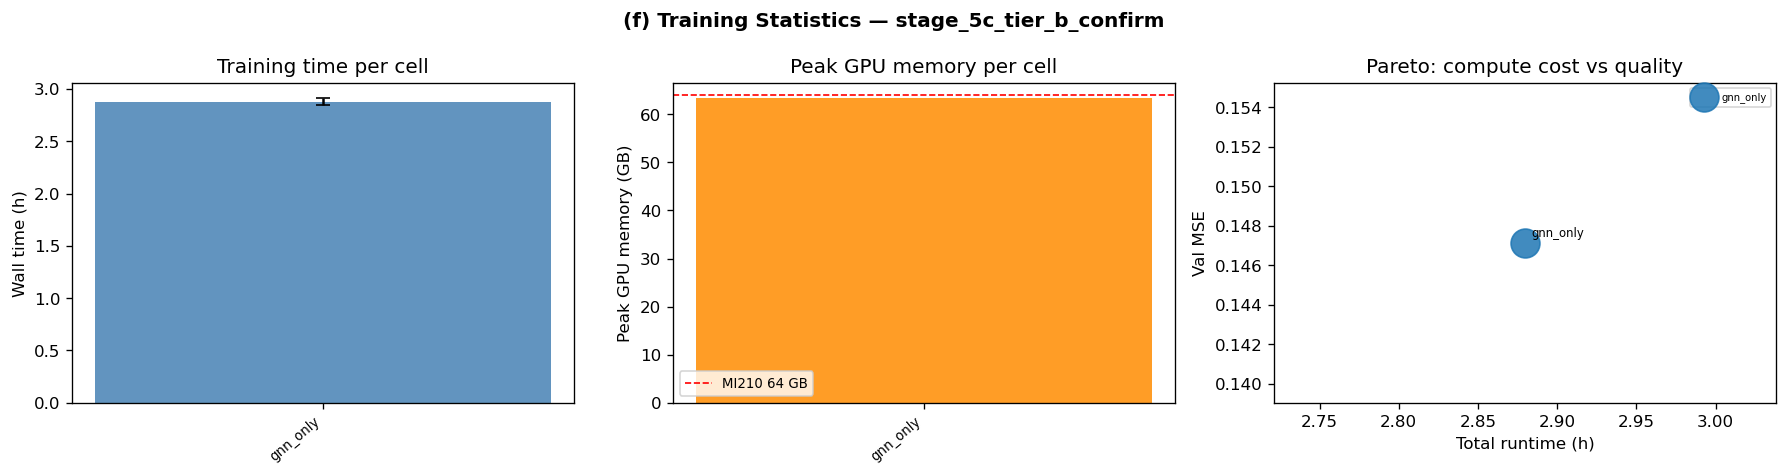

In [11]:
# ── (f) Training-stats panel ───────────────────────────────────────────────────
x_labels = [' | '.join(str(r[k]) for k in GROUP_BY) for _, r in cells_df.iterrows()]
x_pos    = np.arange(len(cells_df))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Wall-time bar chart
ax = axes[0]
rt     = (cells_df['runtime_mean'].fillna(0) / 3600).values
rt_err = (cells_df['runtime_std'].fillna(0) / 3600).values
ax.bar(x_pos, rt, yerr=rt_err, capsize=4, color='steelblue', alpha=0.85)
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Wall time (h)')
ax.set_title('Training time per cell')

# Peak GPU memory bar chart
ax = axes[1]
mem = (cells_df['gpu_mem_mb'].fillna(0) / 1024).values  # GB
bars = ax.bar(x_pos, mem, color='darkorange', alpha=0.85)
ax.axhline(64, color='red', linestyle='--', linewidth=1, label='MI210 64 GB')
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('Peak GPU memory (GB)')
ax.set_title('Peak GPU memory per cell')
ax.legend(fontsize=8)

# Pareto scatter: runtime vs val_mean
ax = axes[2]
valid_p = cells_df.dropna(subset=['runtime_mean', 'val_mean'])
if not valid_p.empty:
    colors_p = plt.cm.tab10(np.linspace(0, 1, len(valid_p)))
    for i, (_, r) in enumerate(valid_p.iterrows()):
        lbl = ' | '.join(str(r[k]) for k in GROUP_BY)
        ax.scatter(r['runtime_mean'] / 3600, r['val_mean'],
                   s=60 * r['n_seeds'], color=colors_p[i], alpha=0.85, zorder=3, label=lbl)
        ax.annotate(lbl, (r['runtime_mean'] / 3600, r['val_mean']),
                    fontsize=7, textcoords='offset points', xytext=(4, 4))
    ax.set_xlabel('Total runtime (h)')
    ax.set_ylabel('Val MSE')
    ax.set_title('Pareto: compute cost vs quality')
    ax.legend(fontsize=6, loc='upper right')
else:
    ax.text(0.5, 0.5, 'No runtime data', ha='center', va='center', transform=ax.transAxes)
    ax.set_title('Pareto: compute cost vs quality')

fig.suptitle(f'(f) Training Statistics — {GROUP}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

Active GPU util column : system.gpu.3.gpu
CPU mem column         : system.proc.memory.availableMB


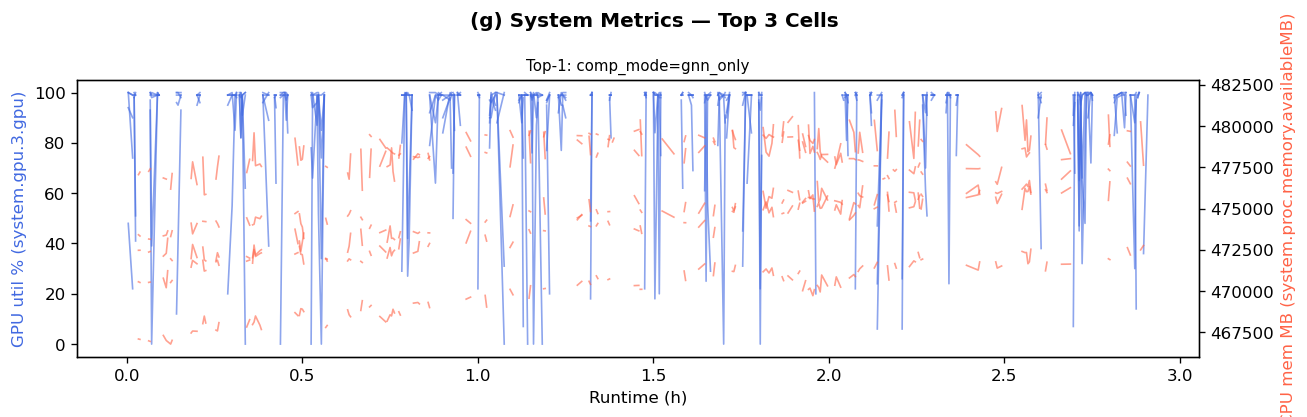

In [12]:
# ── (g) System time-series for top-3 cells ────────────────────────────────────
# Find the active GPU: pick the gpu.N.gpu column with the highest mean value.
# W&B reports all visible GPUs (gpu.0–gpu.7); only the SLURM-allocated one is
# non-zero. The allocated index varies per job, so we can't hardcode gpu.0.
gpu_util_col = None
cpu_mem_col  = None
_best_util   = -1.0
for sys_df in sys_histories.values():
    if sys_df.empty:
        continue
    for c in sys_df.columns:
        low = c.lower()
        if low.endswith('.gpu') and 'gpu' in low:
            m = float(sys_df[c].dropna().mean()) if not sys_df[c].dropna().empty else 0.0
            if m > _best_util:
                _best_util   = m
                gpu_util_col = c
        if cpu_mem_col is None and 'proc' in low and 'mem' in low:
            cpu_mem_col = c

top3     = cells_df.head(3)
n_panels = min(3, len(top3))

has_data = gpu_util_col or cpu_mem_col
if not has_data:
    print('(g) System metrics not available — system.parquet missing or columns not recognised.')
    print('    Probed key patterns: *.gpu (utilisation), proc*mem (CPU memory).')
    if any(not s.empty for s in sys_histories.values()):
        sample = next(s for s in sys_histories.values() if not s.empty)
        print(f'    Available columns: {list(sample.columns)[:20]}')
else:
    print(f'Active GPU util column : {gpu_util_col}')
    print(f'CPU mem column         : {cpu_mem_col}')

    fig, axes = plt.subplots(n_panels, 1, figsize=(11, 3.5 * n_panels), squeeze=False)

    for panel_i, (_, cell_row) in enumerate(top3.head(n_panels).iterrows()):
        ax = axes[panel_i][0]
        cell_runs = runs_df.copy()
        for k in GROUP_BY:
            cell_runs = cell_runs[cell_runs[k] == cell_row[k]]

        label = ' | '.join(f'{k}={cell_row[k]}' for k in GROUP_BY)
        ax2   = None

        for _, r in cell_runs.iterrows():
            sys_df = sys_histories.get(r['run_id'], pd.DataFrame())
            if sys_df.empty or '_runtime' not in sys_df.columns:
                continue
            t = sys_df['_runtime'] / 3600
            if gpu_util_col and gpu_util_col in sys_df.columns:
                ax.plot(t, sys_df[gpu_util_col].values,
                        color='royalblue', alpha=0.6, linewidth=1)
            if cpu_mem_col and cpu_mem_col in sys_df.columns:
                if ax2 is None:
                    ax2 = ax.twinx()
                ax2.plot(t, sys_df[cpu_mem_col].values,
                         color='tomato', alpha=0.6, linewidth=1)

        ax.set_title(f'Top-{panel_i + 1}: {label}', fontsize=9)
        ax.set_xlabel('Runtime (h)')
        if gpu_util_col:
            ax.set_ylabel(f'GPU util % ({gpu_util_col})', color='royalblue')
        if ax2 is not None:
            ax2.set_ylabel(f'CPU mem MB ({cpu_mem_col})', color='tomato')

    fig.suptitle('(g) System Metrics — Top 3 Cells', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Recommendation

Selection rules (from `docs/gnn_only_hp_search_plan.md` §Verification):
1. **Primary**: lowest `val_mean` (= mean over seeds of min val/loss_total last 10 epochs).
2. **Tie-break** within `OCCAM_TOL` of leader: smaller `val_std` → smaller `gap` → smaller model.
3. **Gate check**: per-property val MSE vs. Stage-5 acceptance thresholds.

In [13]:
# ── Recommendation ─────────────────────────────────────────────────────────────
if cells_df.empty:
    print('No cells to rank.')
else:
    best = cells_df.iloc[0]
    best_val = best['val_mean']

    print('=' * 64)
    print(f'  RECOMMENDED HP COMBINATION  ({GROUP})')
    print('=' * 64)
    for k in GROUP_BY:
        print(f'  {k:<22}: {best[k]}')
    print(f'  {"val_mean":<22}: {best_val:.4f} +/- {best["val_std"]:.4f}')
    print(f'  {"test_mean":<22}: {best["test_mean"]:.4f}')
    gap_val = best['gap']
    print(f'  {"gap |test - val|":<22}: {gap_val:.4f}')
    print(f'  {"n_seeds":<22}: {int(best["n_seeds"])}')
    print()

    # Tie-break check
    runner_ups = cells_df.iloc[1:]
    if not runner_ups.empty and not np.isnan(best_val):
        thresh = best_val * (1 + OCCAM_TOL)
        close  = runner_ups[runner_ups['val_mean'] <= thresh]
        if not close.empty:
            print(f'  NOTE: {len(close)} cell(s) within {OCCAM_TOL*100:.0f}% of leader (check Occam tie-break):')
            for _, r in close.iterrows():
                lbl = ' | '.join(f'{k}={r[k]}' for k in GROUP_BY)
                print(f'    {lbl}  val={r["val_mean"]:.4f}  std={r["val_std"]:.4f}')
            print()

    # Per-property gate check (MSE-based — the selection metric)
    print('  Stage-5 acceptance gates (val MSE):')
    for prop, gate in GATES.items():
        col = f'val_{prop}'
        if col in best.index and not np.isnan(best[col]):
            status = 'PASS' if best[col] < gate else 'FAIL'
            print(f'    {prop:<20}: {status}  val={best[col]:.4f}  gate={gate}')
        else:
            print(f'    {prop:<20}: N/A  (property not in this group)')

    # Per-property R² (reporting metric — last-10 mean, mean over seeds).
    # R² is noisy on small val sets, so val_min_last10 of MSE is the selection
    # metric. R² is shown here as a complementary, interpretable quality signal:
    #   R² ≈ 1.0  → near-perfect
    #   R² ≈ 0.5  → moderate (typical for noisy second-moment properties)
    #   R² ≤ 0    → worse than predicting the dataset mean (failure)
    print()
    print('  Per-property R² (last-10 mean, mean over seeds):')
    for prop in PROPS:
        r2_col = f'r2_{prop}'
        if r2_col in best.index and not np.isnan(best[r2_col]):
            r2_val = best[r2_col]
            tag = 'GOOD' if r2_val >= 0.85 else ('OK' if r2_val >= 0.5 else 'WEAK')
            print(f'    {prop:<20}: R²={r2_val:.3f}  [{tag}]')

    print()
    print('  --> Use this config for Stage 5 (5-seed confirmation run).')

  RECOMMENDED HP COMBINATION  (stage_5c_tier_b_confirm)
  comp_mode             : gnn_only
  val_mean              : 0.1471 +/- 0.0114
  test_mean             : 0.1243
  gap |test - val|      : 0.0228
  n_seeds               : 5

  Stage-5 acceptance gates (val MSE):
    lipid_packing       : FAIL  val=0.0223  gate=0.019
    thickness           : FAIL  val=0.0717  gate=0.067
    thickness_std       : PASS  val=0.2938  gate=0.302
    variation           : PASS  val=0.0878  gate=0.151
    persistence         : PASS  val=0.3425  gate=0.362
    diffusivity         : FAIL  val=0.0629  gate=0.059

  Per-property R² (last-10 mean, mean over seeds):
    lipid_packing       : R²=0.935  [GOOD]
    thickness           : R²=0.944  [GOOD]
    thickness_std       : R²=0.644  [OK]
    variation           : R²=0.941  [GOOD]
    persistence         : R²=0.679  [OK]
    diffusivity         : R²=0.953  [GOOD]

  --> Use this config for Stage 5 (5-seed confirmation run).


## Multi-group comparison (optional)

Set `GROUPS = ['stage_0_baseline', 'stage_1_lr', 'stage_2_wd', 'stage_3_arch']`
at the top of Cell 1 to see whether each stage improved on the previous one.

Loaded 5 runs from 'stage_0c_tier_b'
Loaded 6 runs from 'stage_1e_tier_b_lr'
Loaded 12 runs from 'stage_1e_refine_tier_b_lr'
Loaded 5 runs from 'stage_5c_tier_b_confirm'


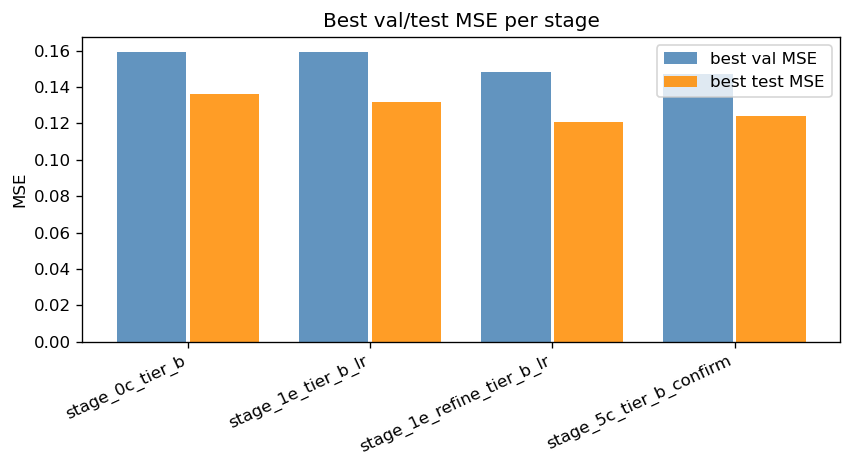

,group,best_val,best_test
0,stage_0c_tier_b,0.1595,0.1363
1,stage_1e_tier_b_lr,0.1594,0.1316
2,stage_1e_refine_tier_b_lr,0.1481,0.1208
3,stage_5c_tier_b_confirm,0.1471,0.1243


In [14]:
# ── Multi-group comparison ─────────────────────────────────────────────────────
if not GROUPS:
    print('Set GROUPS = [...] in Cell 1 to enable multi-group comparison.')
else:
    group_bests = []
    for g in GROUPS:
        try:
            gdf, _, _ = load_group(g)
            ghps = [
                c for c in HP_COLS
                if c in gdf.columns and gdf[c].nunique() > 1
            ]
            gby = ghps if ghps else ['comp_mode']
            gcells = _agg_cells(gdf, gby)
            group_bests.append({
                'group':     g,
                'best_val':  gcells['val_mean'].min(),
                'best_test': gcells['test_mean'].min(),
            })
        except FileNotFoundError as exc:
            print(f'  Skipping {g}: {exc}')

    if group_bests:
        gb_df = pd.DataFrame(group_bests)
        x = np.arange(len(gb_df))

        fig, ax = plt.subplots(figsize=(max(6, len(gb_df) * 1.8), 4))
        ax.bar(x - 0.2, gb_df['best_val'],  width=0.38, label='best val MSE',
               color='steelblue', alpha=0.85)
        ax.bar(x + 0.2, gb_df['best_test'], width=0.38, label='best test MSE',
               color='darkorange', alpha=0.85)
        ax.set_xticks(x)
        ax.set_xticklabels(gb_df['group'], rotation=25, ha='right')
        ax.set_ylabel('MSE')
        ax.set_title('Best val/test MSE per stage')
        ax.legend()
        plt.tight_layout()
        plt.show()

        display(gb_df.round(4))